In [2]:
# 定义一个字典，将数字标签映射为对应的中文名称
classification_names = {
    0: '上身衣服',  # 数字 0 对应“上身衣服”
    1: '鞋',       # 数字 1 对应“鞋”
    2: '包',       # 数字 2 对应“包”
    3: '下身衣服',  # 数字 3 对应“下身衣服”
    4: '手表'      # 数字 4 对应“手表”
}

In [3]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset,DataLoader,random_split  # 数据集处理模块

from PIL import Image
import re

In [4]:
# 1.数据提取
# 1.1 先构造一个函数，能够将图片文件名按照字母及数字大小排序
def sorted_alphanum(image_names):  # 传入的是一个列表
    # 定义转换函数
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    # 定义key
    alphanum_key = lambda img_name: [convert(x) for x in re.split('([0-9]+)', img_name)]
    return sorted(image_names, key=alphanum_key)

# 1.2 自定义数据集类型，元素(image,label)
class ImageLabelDataset(Dataset):
    def __init__(self,image_dir,transform=None):
        # 将文件的读取路径和图片的转换操作transform定义为属性，方便后面随时调用
        self.main_dir = image_dir
        self.transform = transform
        self.image_names = sorted_alphanum(os.listdir(image_dir))  # 获取目录下所有图片文件名，并按照字母数字顺序混合排序
        self.labels = pd.read_csv('../common/fashion-labels.csv')
        # 用拉链函数创造一个字典，便于后续查询target，拉链返回的格式为{id:label}
        self.label_dict = dict(zip(self.labels['id'],self.labels['target']))

    def __len__(self):
        return len(self.image_names)

    # 传入图片id，获取数据集元素(x,y)
    def __getitem__(self, idx):
        # 1 根据索引号构建图片的完整路径
        image_loc = os.path.join(self.main_dir,self.image_names[idx])
        # 2 使用PIL打开图片,并转换格式，变成RGB三通道数据
        image = Image.open(image_loc).convert('RGB')
        # 3 利用transform转换成tensor
        if self.transform is not None:
            tensor_image = self.transform(image)
        else:
            # 如果为None，抛出异常
            raise ValueError('transform cannot be None!')
        # 4 在字典中找出图片对应的标签
        label = torch.tensor(self.label_dict[idx])
        return  tensor_image,label

In [5]:
import torchvision.transforms as transforms  # 图像预处理模块

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
])

# 测试主流程
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')


full_dataset = ImageLabelDataset(image_dir='../common/dataset/',transform=transform)
print(len(full_dataset))

24853


In [6]:
train_dataset,test_dataset = random_split(full_dataset,[0.75,0.25])
print(len(train_dataset))
print(len(test_dataset))

18640
6213


In [7]:
batch_size = 32
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader= DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [8]:
for (x,y) in train_loader:
    print(x.shape,y.shape)
    break

torch.Size([32, 3, 64, 64]) torch.Size([32])


In [9]:
# 定义模型
import torch.nn as nn
class Classifier(nn.Module):
    def __init__(self,n_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3,8,kernel_size=3,stride=1,padding=1)
        self.conv2 = nn.Conv2d(8,16,kernel_size=3,stride=1,padding=1)
        # 通用池化层,池化层没有参数更新，故可以定义通用池化层
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        # 全连接层
        self.linear = nn.Linear(16*16*16,n_classes)

    def forward(self, x):
        # 第一层卷积
        x = torch.relu(self.conv1(x))
        # 第一层池化
        x = self.pool(x)
        # 第二层卷积
        x = torch.relu(self.conv2(x))
        # 第二层池化
        x = self.pool(x)
        # 扁平化处理
        x = x.reshape(x.shape[0],-1)
        # 线性层
        x = self.linear(x)
        return x

In [10]:
model = Classifier()
# 获取一批数据进行测试
data_iter = iter(train_loader)
x,y = next(data_iter)
output = model(x)
print(output.shape)

torch.Size([32, 5])


In [11]:
# 模型训练
# 定义损失函数
loss = nn.CrossEntropyLoss()
# 定义优化器
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)
# 训练轮次
model.to(device)
num_epochs = 10
for epoch in range(1,num_epochs+1):
    train_loss = 0
    for x,y in train_loader:
        x,y = x.to(device),y.to(device)
        output = model(x)  # 前向传播
        loss_value = loss(output,y)
        loss_value.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += loss_value * x.shape[0]
    print(f'第{epoch}轮损失值为：{train_loss/len(train_dataset)}')

第1轮损失值为：0.23255738615989685
第2轮损失值为：0.1058700829744339
第3轮损失值为：0.08146928250789642
第4轮损失值为：0.07165736705064774
第5轮损失值为：0.05291927233338356
第6轮损失值为：0.0533197820186615
第7轮损失值为：0.0652736946940422
第8轮损失值为：0.047825589776039124
第9轮损失值为：0.05064963176846504
第10轮损失值为：0.039229802787303925


In [12]:
# 验证测试
data_iter = iter(test_loader)
x,y = next(data_iter)

In [13]:
model.to(device)
x = x.to(device)
# 前向传播，计算输出
output = model(x)
output = output.detach().cpu().numpy()
print(output.shape)

(32, 5)


In [14]:
x = x.permute(0,2,3,1).detach().cpu().numpy()
print(x.shape)

(32, 64, 64, 3)


1-label:2
1-output:包
2-label:1
2-output:鞋
3-label:1
3-output:鞋
4-label:0
4-output:上身衣服
5-label:1
5-output:鞋
6-label:0
6-output:上身衣服
7-label:0
7-output:上身衣服
8-label:0
8-output:上身衣服
9-label:4
9-output:手表
10-label:2
10-output:包


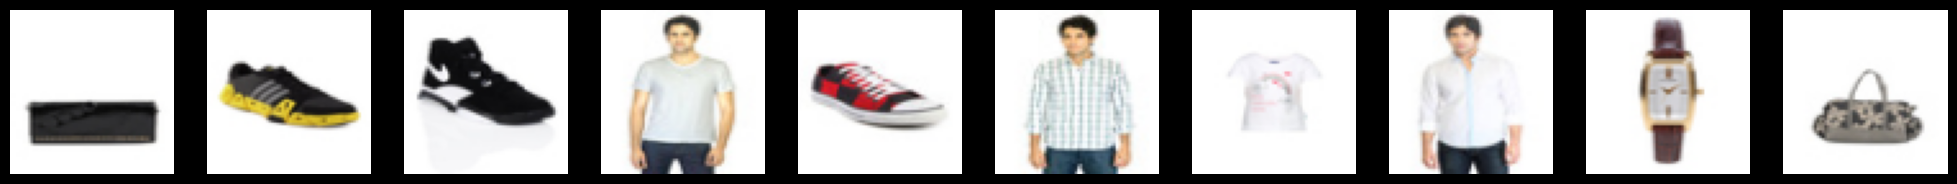

In [15]:
# 画图
import matplotlib.pyplot as plt
fig,axes = plt.subplots(1,10,figsize=(25,4))
for i,ax in enumerate(axes):
    ax.imshow(x[i])
    ax.axis('off')
    # 打印真实分类标签
    print(f'{i+1}-label:{y[i]}')
    # 打印预测值
    print(f'{i+1}-output:{classification_names[output.argmax(axis=1)[i]]}')
plt.show()